# Tree Starts Notebook

This notebook will be used to train and evaluate Random Forest models. The Random Forest model will first be run without being corrected, and then run after preprocessing to compare the results.
This was done after initial work and so is missing some explatory steps of this work (all other files will be saved in an appendix folder).

In the notebook you will find the below:

1. [Data and EDA](#read-in-data-and-eda)
2. [Setting up the model](#setting-up-the-model)
3. [Baseline model](#baseline-model)
4. [Hyperparameter tuning](#hyperparameter-tuning)
5. [Comparing the results](#results-comparison)


The different data sources:
1. data/target/model_training_data.csv: 
2. data/target/model_training_data_new.csv
3. data/target/model_training_data_new_2.csv: 
4. data/target/model_training_data_new_3.csv: includes new availability column

Read in the necessary libraries:

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor, HistGradientBoostingRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,precision_score, recall_score
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import networkx as nx
from itertools import product
import pickle
import lightgbm as lgb
import xgboost as xgb
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.exceptions import DataConversionWarning
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVR
import matplotlib.colors as mcolors
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'Helvetica'
warnings.filterwarnings('ignore', category=DataConversionWarning)
%matplotlib inline

**Needed Function Definitions**

In [ ]:
#helper functions 
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0].keys()

# data cleaning functions
def find_bad_storms(df, na_columns):
    # find storms where ALL values are null for any of the cols
    bad_storms = []
    for storm in df['typhoon_name'].unique():
        for col in na_columns:
            if df[df['typhoon_name'] == storm][col].isna().all():
                bad_storms.append(storm)
                break  # no need to check other cols

    bad_storms = list(set(bad_storms))
    return bad_storms

def calculate_storm_medians(df, cols):
    '''
    This function will calculate storm-specific medians for the affected cells and creates a dictionary
    so we can do this for the test set as well.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            prob_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 1)][col].median()
            not_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 0)][col].median()
            overall_median = df[df['typhoon_name'] == storm][col].median()

            storm_medians[storm][col] = {
                'prob_aff': prob_median,
                'not_affected': not_median,
                'overall_median': overall_median
            }
    return storm_medians

def get_storm_median_for_row(row, storm_medians, col):
    '''
    This function will get the storm-specific medians for a given row, and will check if the s
    '''
    storm_name = row['typhoon_name']
    
    # fallback if storm not seen during training
    if storm_name not in storm_medians:
        return np.nan  # or a global median you pass in
    
    medians = storm_medians[storm_name][col]
    
    if row['prob_aff'] == 1 and not pd.isna(medians['prob_aff']):
        return medians['prob_aff']
    elif row['prob_aff'] == 0 and not pd.isna(medians['not_affected']):
        return medians['not_affected']
    else:
        return medians['overall_median']
    

def drop_correlated_features(X_train,y_train,method='spearman',thresh=0.75):
    
    corr_cols_to_drop = []
    cols_to_skip = []

    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > thresh:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop

def complex_imputation_of_dataset(X_train, X_test, na_cols):
    median_dict = calculate_storm_medians(X_train, na_cols)

    # now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
    for col in na_cols:
        # only impute where null — preserve existing values
        null_mask_train = X_train[col].isna()
        null_mask_test = X_test[col].isna()

        X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
            lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
        )
        X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
            lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
        )

    return X_train, X_test

def clean_and_split_data(df, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75):
    
    # get data
    y = df[main_target]
    X = df.drop(columns=target_cols)

    # drop columns with >95% nulls
    nas_finder = df.isna().sum()
    too_null_cols = [i for i in nas_finder[nas_finder > 0].index if nas_finder.loc[i] / df.shape[0] > 0.95]
    X.drop(columns=too_null_cols, inplace=True)

    # make NA indicator columns
    for i in X.columns[X.isna().any()]:
        X[f'{i}_isna'] = X[i].isna().astype(int)

    # remove storms that have no values for any NA column
    na_cols = get_na_columns(X)
    bad_storms = find_bad_storms(X, na_cols)
    mask = ~X['typhoon_name'].isin(bad_storms)
    X, y = X[mask], y[mask]

    # drop single-value columns
    cols_to_drop = [col for col in X.columns if X[col].nunique() == 1]
    X.drop(columns=cols_to_drop, inplace=True)

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    na_cols = get_na_columns(X_train)

    if filling_method == 'simple':
        # plain column medians from training set only
        col_medians = X_train[na_cols].median()
        X_train[na_cols] = X_train[na_cols].fillna(col_medians)
        X_test[na_cols]  = X_test[na_cols].fillna(col_medians)

    elif filling_method == 'complex':
        # storm-specific medians, falling back to global median for unseen storms
        global_medians = X_train[na_cols].median().to_dict()
        X_train, X_test = complex_imputation_of_dataset(X_train, X_test, na_cols)
        # apply global median fallback for any remaining nulls (unseen storms in test)
        X_test[na_cols] = X_test[na_cols].fillna(global_medians)

    # drop typhoon_name
    X_train.drop(columns=['typhoon_name'], inplace=True)
    X_test.drop(columns=['typhoon_name'], inplace=True)

    if remove_corr_cols:
        aff_cols = [c for c in X_train.columns if 'aff' in c]
        corr_cols_to_drop = drop_correlated_features(X_train.drop(columns=aff_cols), y_train, 'spearman', thresh)
        X_train.drop(columns=corr_cols_to_drop, inplace=True)
        X_test.drop(columns=corr_cols_to_drop, inplace=True)

    return X_train, X_test, y_train, y_test

def find_correlated_groups(X, method='spearman', thresh=0.75):
    corr = X.corr(method=method).abs()
    G = nx.Graph()
    G.add_nodes_from(X.columns)
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if corr.iloc[i, j] > thresh:
                G.add_edge(corr.columns[i], corr.columns[j])
    groups = [list(c) for c in nx.connected_components(G) if len(c) > 1]
    return groups


def select_representative(group, X_train, y_train, method='spearman', must_include=None):
    # if a must_include col is in this group, return it immediately
    if must_include and must_include in group:
        print(f"Pinned '{must_include}' as representative (must_include)")
        return must_include
    correlations = {col: abs(X_train[col].corr(y_train, method=method)) for col in group}
    return max(correlations, key=correlations.get)


def select_best_features(X_train, y_train, groups, model,
                         method='spearman', large_group_thresh=5, cv=5,
                         must_include=None,max_combos=200):
    must_include = must_include or []
    if isinstance(must_include, str):
        must_include = [must_include]

    all_corr_cols = [col for group in groups for col in group]
    base_cols     = [col for col in X_train.columns if col not in all_corr_cols]

    # ensure any must_include cols that aren't in any group are always in base
    for col in must_include:
        if col not in base_cols and col not in all_corr_cols:
            print(f"Warning: '{col}' not found in X_train columns — skipping")
        if col in all_corr_cols and col not in base_cols:
            pass  # handled per-group below

    selected_from_groups = []
    small_groups = []

    for group in groups:
        pinned = [col for col in must_include if col in group]

        if len(group) > large_group_thresh:
            if pinned:
                # pin the must_include col instead of picking by correlation
                best_col = pinned[0]
                print(f"Large group ({len(group)} features) → pinned: {best_col}")
            else:
                best_col = select_representative(group, X_train, y_train, method)
                print(f"Large group ({len(group)} features) → selected: {best_col}")
            selected_from_groups.append([best_col])
        else:
            if pinned:
                # remove the pinned col from the group so it's not part of
                # the exhaustive search — it'll be added back via fixed_cols
                group = [col for col in group if col not in pinned]
                print(f"Pinning {pinned} from small group, searching remaining {len(group)} cols")
                selected_from_groups.append(pinned)
                if group:
                    small_groups.append(group)
            else:
                small_groups.append(group)

    # exhaustive search over small groups
    if small_groups:
        combos = list(product(*small_groups))
        
        # subsample if too many combinations
        if len(combos) > max_combos:
            import random
            random.seed(42)
            combos = random.sample(combos, max_combos)
            print(f"Subsampled to {max_combos} combinations")
        
        print(f"Searching {len(combos)} combinations from {len(small_groups)} small groups...")
        best_score = -np.inf
        best_combo = None
        fixed_cols = base_cols + [col for group in selected_from_groups for col in group]

        for combo in combos:
            cols = fixed_cols + list(combo)
            scores = cross_val_score(model, X_train[cols], y_train, cv=cv, scoring='r2')
            mean_score = scores.mean()
            if mean_score > best_score:
                best_score = mean_score
                best_combo = combo

        print(f"Best exhaustive combo score: {best_score:.4f}")
        selected_from_groups.append(list(best_combo))

    final_cols = base_cols + [col for group in selected_from_groups for col in group]

    # final safety net — guarantee must_include cols are always present
    for col in must_include:
        if col not in final_cols and col in X_train.columns:
            print(f"Safety net: force-adding '{col}'")
            final_cols.append(col)

    print(f"\nFinal feature count: {len(final_cols)} from original {len(X_train.columns)}")
    return final_cols

def print_consistent_results(model, X_train, y_train, X_test, y_test, cv=5, sample_weight=None):
    '''
    This function takes the model we have, the training and test data, and prints out the 
    cross-validation R² and RMSE (with mean and std), as well as the test set R² and RMSE. 
    This way we can have a consistent way to evaluate different models and compare them.
    '''
    # Cross-validation with R²
    params = {'sample_weight': sample_weight} if sample_weight is not None else {}

    r2_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2',
                                params=params)
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    
    # Cross-validation with RMSE
    rmse_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error',
                                  params=params)
    mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
    std_rmse = np.std(rmse_scores)
    
    # Train and predict
    model.fit(X_train, y_train, **params)
    y_pred = model.predict(X_test)
    
    # Test set metrics
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
    print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
    print(f"Test Set R²:           {test_r2:.4f}")
    print(f"Test Set RMSE:         {test_rmse:.4f}")

def try_out_models_for_col_thresh(X_train,X_test,y_train,y_test,model,col,thresh=0.2):
    train_mask = X_train[col] >= thresh
    test_mask = X_test[col] >= thresh

    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    X_test = X_test[test_mask]
    y_test = y_test[test_mask]

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mean_score = scores.mean()
    print(f"mean CV score: {mean_score} with thresh: {thresh}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"R²: {r2_score(y_test, y_pred):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    return

def best_lgbm_tester(model,X_train,y_train,X_test,y_test,thresh=0.9):
    corr_cols_to_drop_wo_2 = drop_correlated_features(X_train, y_train_c, 'spearman', 0.9)
    X_train_simp = X_train.drop(columns=corr_cols_to_drop_wo_2)
    X_test_simp = X_test.drop(columns=corr_cols_to_drop_wo_2)

    # best_lgbm_wo_grid.fit(X_train_c_simp_selec_wo,y_train_c)
    print_consistent_results(model, X_train_simp, y_train, 
                            X_test_simp, y_test, cv=5)

    sample_weights = np.where(
        X_train_wo_grid.loc[X_train_simp.index, 'perc_available_upscaled_new'] >= 0.05,
        2.0, 0.5
    )
    print_consistent_results(model, X_train_simp, y_train,
                            X_test_simp, y_test, cv=5,sample_weight=sample_weights)
    
    return

Read in the already cleaned and split data:

In [3]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final.csv')
X_train_c, X_test_c, y_train_c, y_test_c = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

# read in simple filled data
X_train_s, X_test_s, y_train_s, y_test_s = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='simple')


Quick baseline models with both sets:

In [ ]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(rf_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_c)
test_r2_rfb = r2_score(y_test_c, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(ex_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_c)
test_r2_exb = r2_score(y_test_c, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_c, y_train_c)

scores = cross_val_score(lgb_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_c)
test_r2_lgb = r2_score(y_test_c, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(hgbr_model, X_train_c, y_train_c, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_c)
test_r2_hgbr = r2_score(y_test_c, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_c, y_train_c)

scores = cross_val_score(br_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_c)
test_r2_br = r2_score(y_test_c, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_c, y_train_c)

scores = cross_val_score(gbr_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_c)
test_r2_gbr = r2_score(y_test_c, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_c, y_train_c)

scores = cross_val_score(xgb_b_model, X_train_c, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_c)
test_r2_xgbb = r2_score(y_test_c, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_c.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_c.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_c, y_pred_svr):.4f}")

#Results:
# for RandomForest:
# mean CV score: 0.2572
# Test Set R²: 0.3340
# for ExtraTrees:
# mean CV score: 0.1586
# Test Set R²: 0.3038
# for LGBM:
# mean CV score: 0.2382
# Test Set R²: 0.3056
# for HistGradientBoostingRegressor:
# mean CV score: 0.2364
# Test Set R²: 0.2871
# for BaggingRegressor:
# mean CV score: 0.1889
# Test Set R²: 0.2291
# for GradientBoostingRegressor:
# mean CV score: 0.1506
# Test Set R²: 0.1648
# for XGBRegressor:
# mean CV score: 0.1675
# Test Set R²: 0.2617
# for SVR:
# mean CV score: -0.0099
# Test R²: -0.0106

for RandomForest:
mean CV score: 0.2572
Test Set R²: 0.3340
for ExtraTrees:
mean CV score: 0.1586
Test Set R²: 0.3038
for LGBM:
mean CV score: 0.2382
Test Set R²: 0.3056
for HistGradientBoostingRegressor:
mean CV score: 0.2364
Test Set R²: 0.2871
for BaggingRegressor:
mean CV score: 0.1889
Test Set R²: 0.2291
for GradientBoostingRegressor:
mean CV score: 0.1506
Test Set R²: 0.1648
for XGBRegressor:
mean CV score: 0.1675
Test Set R²: 0.2617
for SVR:
mean CV score: -0.0099
Test R²: -0.0106


now for the simple filling:

In [ ]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_s, y_train_s)

scores = cross_val_score(rf_b_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_s)
test_r2_rfb = r2_score(y_test_s, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_s, y_train_s)

scores = cross_val_score(ex_b_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_s)
test_r2_exb = r2_score(y_test_s, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_s, y_train_s)

scores = cross_val_score(lgb_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_s)
test_r2_lgb = r2_score(y_test_s, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_s, y_train_s)

scores = cross_val_score(hgbr_model, X_train_s, y_train_s, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_s)
test_r2_hgbr = r2_score(y_test_s, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_s, y_train_s)

scores = cross_val_score(br_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_s)
test_r2_br = r2_score(y_test_s, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_s, y_train_s)

scores = cross_val_score(gbr_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_s)
test_r2_gbr = r2_score(y_test_s, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_s, y_train_s)

scores = cross_val_score(xgb_b_model, X_train_s, y_train_s, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_s)
test_r2_xgbb = r2_score(y_test_s, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test_s)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_s.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_c.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_s, y_pred_svr):.4f}")

# Results:
# for RandomForest:
# mean CV score: -0.0073
# Test Set R²: 0.0899
# for ExtraTrees:
# mean CV score: -0.0934
# Test Set R²: 0.1405
# for LGBM:
# mean CV score: 0.1386
# Test Set R²: 0.2331
# for HistGradientBoostingRegressor:
# mean CV score: 0.1247
# Test Set R²: 0.1989
# for BaggingRegressor:
# mean CV score: -0.0811
# Test Set R²: 0.0347
# for GradientBoostingRegressor:
# mean CV score: 0.1026
# Test Set R²: 0.1100
# for XGBRegressor:
# mean CV score: 0.0709
# Test Set R²: 0.1540
# for SVR:
# mean CV score: -0.0105
# Test R²: -0.0113

for RandomForest:
mean CV score: -0.0073
Test Set R²: 0.0899
for ExtraTrees:
mean CV score: -0.0934
Test Set R²: 0.1405
for LGBM:
mean CV score: 0.1386
Test Set R²: 0.2331
for HistGradientBoostingRegressor:
mean CV score: 0.1247
Test Set R²: 0.1989
for BaggingRegressor:
mean CV score: -0.0811
Test Set R²: 0.0347
for GradientBoostingRegressor:
mean CV score: 0.1026
Test Set R²: 0.1100
for XGBRegressor:
mean CV score: 0.0709
Test Set R²: 0.1540
for SVR:
mean CV score: -0.0105
Test R²: -0.0113


Ok, best base model here was: _RandomForest_ (with LGBM right behind). 

The complex filled preformed better, and we saw this in the earlier work, so we'll go forward with that filling. Next, we'll do some cleaning of the data etc to see how we can get the grided model to go, and then will do the ungridded model after. 

First, lets run a dummy model to have this compare to: 

In [ ]:
dummy = DummyRegressor(strategy='median')

dummy_r2 = cross_val_score(dummy, X_train_c, y_train_c, scoring='r2', cv=5)
print(f"Baseline R²: {dummy_r2.mean():.4f}")

# Also check on test set
dummy.fit(X_train_c, y_train_c)
y_pred_dummy = dummy.predict(X_test_c)
print(f"Baseline Test R²: {r2_score(y_test_c, y_pred_dummy):.4f}")

print_consistent_results(dummy, X_train_c, y_train_c, X_test_c, y_test_c, cv=5)

# Baseline R²: -0.0155
# Baseline Test R²: -0.0162
# Cross-validation R²:   -0.0155 ± 0.0012
# Cross-validation RMSE: 4.9939 ± 0.4396
# Test Set R²:           -0.0162
# Test Set RMSE:         5.2641

Baseline R²: -0.0155
Baseline Test R²: -0.0162
Cross-validation R²:   -0.0155 ± 0.0012
Cross-validation RMSE: 4.9939 ± 0.4396
Test Set R²:           -0.0162
Test Set RMSE:         5.2641


Ok, inital model, this one we'll definitly need to get rid of some of the data becuase it reduced it's accuracy with some of the new additions:

In [ ]:
model_init_1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1,
)

print("results for: model_training_data_final.csv")
print_consistent_results(model_init_1, X_train_c, y_train_c, X_test_c, y_test_c, cv=5)

# results for: model_training_data_final.csv
# Cross-validation R²:   0.2593 ± 0.0177
# Cross-validation RMSE: 4.2611 ± 0.3398
# Test Set R²:           0.3314
# Test Set RMSE:         4.2699

results for: model_training_data_new_2.csv
Cross-validation R²:   0.2593 ± 0.0177
Cross-validation RMSE: 4.2611 ± 0.3398
Test Set R²:           0.3314
Test Set RMSE:         4.2699


Showing result comparions with scaling of features before selecting for best features:

In [27]:
scaler = StandardScaler()
pipeline_init_1 = Pipeline([('s', scaler), ('m', model_init_1)])

print_consistent_results(pipeline_init_1, X_train_c, y_train_c, X_test_c, y_test_c, cv=5)

Cross-validation R²:   0.2599 ± 0.0182
Cross-validation RMSE: 4.2595 ± 0.3417
Test Set R²:           0.3302
Test Set RMSE:         4.2739


In [28]:
binary_cols = [c for c in X_train_c.columns if X_train_c[c].nunique() == 2]
continuous_cols = [c for c in X_train_c.columns if c not in binary_cols]

preprocessor = ColumnTransformer([
    ('scale', PowerTransformer(), continuous_cols),
    ('passthrough', 'passthrough', binary_cols)
])

pipeline_init_2 = Pipeline([('pre', preprocessor), ('m', model_init_1)])

print_consistent_results(pipeline_init_2, X_train_c, y_train_c, X_test_c, y_test_c, cv=5)

Cross-validation R²:   0.2452 ± 0.0352
Cross-validation RMSE: 4.2965 ± 0.3015
Test Set R²:           0.3221
Test Set RMSE:         4.2996


In [30]:
scaler = MinMaxScaler()
pipeline_init_2 = Pipeline([('s',scaler),('m',model_init_1)])

# cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# # evaluate the model
# # m_scores = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
# # rmse_scores = (-m_scores) ** 0.5
# # print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

# r2_scores_scale = cross_val_score(pipeline, X_train_w_grid, y_train, scoring='r2', cv=cv, n_jobs=-1)
# print(f"R2:   {r2_scores_scale.mean():.4f} ± {r2_scores_scale.std():.4f}")

print_consistent_results(pipeline_init_2, X_train_c, y_train_c, X_test_c, y_test_c, cv=5)

Cross-validation R²:   0.2552 ± 0.0243
Cross-validation RMSE: 4.2710 ± 0.3245
Test Set R²:           0.3280
Test Set RMSE:         4.2807


Select best columns for model:

In [ ]:
groups = find_correlated_groups(X_train_c,thresh=0.80)

cols_init_full = select_best_features(X_train_c, y_train_c, groups, model_init_1, 
                         method='spearman', large_group_thresh=5, cv=5,must_include='grid_point_id')

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (9 features) → selected: mean_available
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna

Exhaustive search over 4608 combinations from 10 small groups...


Look into the baselines without the `grid_point_id`:

In [4]:
#without grid
X_train_wo_grid = X_train_c.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_c.drop(columns=['grid_point_id'])

we'll start with the overall search again just to make sure this is the correct model to go forward with:

In [ ]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
rf_b_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(rf_b_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_rfb = rf_b_model.predict(X_test_wo_grid)
test_r2_rfb = r2_score(y_test_c, y_pred_rfb)
print(f"Test Set R²: {test_r2_rfb:.4f}")

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
ex_b_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(ex_b_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_exb = ex_b_model.predict(X_test_wo_grid)
test_r2_exb = r2_score(y_test_c, y_pred_exb)
print(f"Test Set R²: {test_r2_exb:.4f}")

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
lgb_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(lgb_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_lgb = lgb_model.predict(X_test_wo_grid)
test_r2_lgb = r2_score(y_test_c, y_pred_lgb)
print(f"Test Set R²: {test_r2_lgb:.4f}")

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
hgbr_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(hgbr_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2',verbose=0)
print(f"mean CV score: {scores.mean():.4f}")

y_pred_hgbr = hgbr_model.predict(X_test_wo_grid)
test_r2_hgbr = r2_score(y_test_c, y_pred_hgbr)
print(f"Test Set R²: {test_r2_hgbr:.4f}")

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
br_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(br_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_br = br_model.predict(X_test_wo_grid)
test_r2_br = r2_score(y_test_c, y_pred_br)
print(f"Test Set R²: {test_r2_br:.4f}")

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
gbr_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(gbr_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_gbr = gbr_model.predict(X_test_wo_grid)
test_r2_gbr = r2_score(y_test_c, y_pred_gbr)
print(f"Test Set R²: {test_r2_gbr:.4f}")

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
xgb_b_model.fit(X_train_wo_grid, y_train_c)

scores = cross_val_score(xgb_b_model, X_train_wo_grid, y_train_c, cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_xgbb = xgb_b_model.predict(X_test_wo_grid)
test_r2_xgbb = r2_score(y_test_c, y_pred_xgbb)
print(f"Test Set R²: {test_r2_xgbb:.4f}")

# SVR requires scaling
print("for SVR:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_wo_grid)
X_test_scaled = scaler.transform(X_test_wo_grid)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_c.values.ravel())

scores = cross_val_score(svr_model, X_train_scaled, y_train_c.values.ravel(), cv=5, scoring='r2')
print(f"mean CV score: {scores.mean():.4f}")

y_pred_svr = svr_model.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test_c, y_pred_svr):.4f}")

#Results:
# for RandomForest:
# mean CV score: -0.0098
# Test Set R²: -0.0484
# for ExtraTrees:
# mean CV score: -0.0612
# Test Set R²: -0.1003
# for LGBM:
# mean CV score: 0.0885
# Test Set R²: 0.1014
# for HistGradientBoostingRegressor:
# mean CV score: 0.0975
# Test Set R²: 0.1046
# for BaggingRegressor:
# mean CV score: -0.0602
# Test Set R²: -0.1155
# for GradientBoostingRegressor:
# mean CV score: 0.0820
# Test Set R²: 0.0679
# for XGBRegressor:
# mean CV score: -0.0106
# Test Set R²: 0.0030
# for SVR:
# mean CV score: -0.0103
# Test R²: -0.0110

for RandomForest:
mean CV score: -0.0098
Test Set R²: -0.0484
for ExtraTrees:
mean CV score: -0.0612
Test Set R²: -0.1003
for LGBM:
mean CV score: 0.0885
Test Set R²: 0.1014
for HistGradientBoostingRegressor:
mean CV score: 0.0975
Test Set R²: 0.1046
for BaggingRegressor:
mean CV score: -0.0602
Test Set R²: -0.1155
for GradientBoostingRegressor:
mean CV score: 0.0820
Test Set R²: 0.0679
for XGBRegressor:
mean CV score: -0.0106
Test Set R²: 0.0030
for SVR:
mean CV score: -0.0103
Test R²: -0.0110


Where we don't have the `grid_point_id`, it looks like maybe: `HistGradientBoostingRegressor` and `LGBM` are preforming best.

In [ ]:
param_grid_hgb = {
    "max_iter":        [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "learning_rate":   [0.01, 0.05, 0.1],
    "min_samples_leaf":[10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

grid_hgb_wo = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid_hgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_hgb_wo.fit(X_train_wo_grid, y_train_c)
best_hgb_wo_grid = grid_hgb_wo.best_estimator_

print("Best R²:    ", grid_hgb_wo.best_score_.round(3))
print("Best params:", grid_hgb_wo.best_params_)

print_consistent_results(best_hgb_wo_grid, X_train_wo_grid, y_train_c, X_test_wo_grid, y_test_c, cv=5)

# results:
# Best R²:     0.113
# Best params: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 10}
# Cross-validation R²:   0.1126 ± 0.0326
# Cross-validation RMSE: 4.6640 ± 0.3864
# Test Set R²:           0.1128
# Test Set RMSE:         4.9188

Best R²:     0.113
Best params: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 10}
Cross-validation R²:   0.1126 ± 0.0326
Cross-validation RMSE: 4.6640 ± 0.3864
Test Set R²:           0.1128
Test Set RMSE:         4.9188


In [ ]:
param_grid_lgbm = {
    "n_estimators":   [100, 200, 300],
    "max_depth":      [3, 5, 7, -1],
    "learning_rate":  [0.01, 0.05, 0.1],
    "num_leaves":     [31, 63, 127],
    "min_child_samples": [10, 20, 50],
    "reg_lambda":     [0.0, 0.1, 1.0],
}

grid_lgbm_wo = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid_lgbm,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_lgbm_wo.fit(X_train_wo_grid, y_train_c)
best_lgbm_wo_grid = grid_lgbm_wo.best_estimator_

print("Best R²:    ", grid_lgbm_wo.best_score_.round(3))
print("Best params:", grid_lgbm_wo.best_params_)

print_consistent_results(best_lgbm_wo_grid, X_train_wo_grid, y_train_c, X_test_wo_grid, y_test_c, cv=5)

# results:
# Best R²:     0.109
# Best params: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 1.0}
# Cross-validation R²:   0.1091 ± 0.0341
# Cross-validation RMSE: 4.6755 ± 0.4129
# Test Set R²:           0.1165
# Test Set RMSE:         4.9086


Best R²:     0.109
Best params: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 1.0}
Cross-validation R²:   0.1091 ± 0.0341
Cross-validation RMSE: 4.6755 ± 0.4129
Test Set R²:           0.1165
Test Set RMSE:         4.9086


**Time to do some feature selection for our gridless data**

In [15]:
groups_wo = find_correlated_groups(X_train_wo_grid,thresh=0.80)

cols_wo_grid_hgb = select_best_features(X_train_wo_grid, y_train_c, groups_wo, HistGradientBoostingRegressor(random_state=42), 
                                         method='spearman', large_group_thresh=5, cv=5)

pd.Series(cols_wo_grid_hgb).to_csv('cols_wo_grid_hgb.csv', index=False)

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (9 features) → selected: mean_available
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 10 small groups...
Best exhaustive combo score: 0.0989

Final feature count: 21 from original 67


In [16]:
#groups are the same here as above
cols_wo_grid_lgbm = select_best_features(X_train_wo_grid, y_train_c, groups_wo, lgb.LGBMRegressor(random_state=42, n_jobs=-1), 
                                         method='spearman', large_group_thresh=5, cv=5,must_include='grid_point_id')

pd.Series(cols_wo_grid_lgbm).to_csv('cols_wo_grid_lgbm.csv', index=False)

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (9 features) → selected: mean_available
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 10 small groups...
Best exhaustive combo score: 0.0890

Final feature count: 21 from original 67


In [ ]:
groups_wo_2 = find_correlated_groups(X_train_wo_grid,thresh=0.85)

cols_wo_grid_hgb_2 = select_best_features(X_train_wo_grid, y_train_c, groups_wo_2, HistGradientBoostingRegressor(random_state=42), 
                                         method='spearman', large_group_thresh=5, cv=5)

pd.Series(cols_wo_grid_hgb_2).to_csv('cols_wo_grid_hgb_2.csv', index=False)

# Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
# Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
# Subsampled to 200 combinations
# Searching 200 combinations from 12 small groups...
# Best exhaustive combo score: 0.1004

# Final feature count: 22 from original 67

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 12 small groups...
Best exhaustive combo score: 0.1004

Final feature count: 22 from original 67


In [35]:
groups_wo_3 = find_correlated_groups(X_train_wo_grid,thresh=0.9)

cols_wo_grid_hgb_3 = select_best_features(X_train_wo_grid, y_train_c, groups_wo_3, HistGradientBoostingRegressor(random_state=42), 
                                         method='spearman', large_group_thresh=5, cv=5)

pd.Series(cols_wo_grid_hgb_3).to_csv('cols_wo_grid_hgb_3.csv', index=False)

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 12 small groups...
Best exhaustive combo score: 0.0976

Final feature count: 25 from original 67


In [ ]:
#groups are the same here as above
cols_wo_grid_lgbm_2 = select_best_features(X_train_wo_grid, y_train_c, groups_wo_2, lgb.LGBMRegressor(random_state=42, n_jobs=-1), 
                                         method='spearman', large_group_thresh=5, cv=5,must_include='grid_point_id')

pd.Series(cols_wo_grid_lgbm_2).to_csv('cols_wo_grid_lgbm_2.csv', index=False)

# Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
# Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
# Subsampled to 200 combinations
# Searching 200 combinations from 12 small groups...
# Best exhaustive combo score: 0.0924

# Final feature count: 22 from original 67

Large group (18 features) → selected: prop_not_enough_data_impact_dur_pers_avail30
Large group (8 features) → selected: mean_recov_dur_pers_avail30_isna
Subsampled to 200 combinations
Searching 200 combinations from 12 small groups...
Best exhaustive combo score: 0.0924

Final feature count: 22 from original 67


Ok, now that we have these sets of columns, lets see how they do with our models:

First set:

In [21]:
# best_hgb_wo_grid.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c)
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb], y_train_c,
                          X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)

Cross-validation R²:   0.1105 ± 0.0329
Cross-validation RMSE: 4.6670 ± 0.3547
Test Set R²:           0.0932
Test Set RMSE:         4.9729


In [22]:
# best_lgbm_wo_grid.fit(X_train_wo_grid[cols_wo_grid_lgbm], y_train_c)
print_consistent_results(best_lgbm_wo_grid, X_train_wo_grid[cols_wo_grid_lgbm], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_lgbm], y_test_c, cv=5)

Cross-validation R²:   0.1006 ± 0.0359
Cross-validation RMSE: 4.6966 ± 0.4024
Test Set R²:           0.0925
Test Set RMSE:         4.9746


Second set:

In [36]:
# best_hgb_wo_grid.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c)
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb_2], y_train_c,
                          X_test_wo_grid[cols_wo_grid_hgb_2], y_test_c, cv=5)

Cross-validation R²:   0.0955 ± 0.0391
Cross-validation RMSE: 4.7054 ± 0.3570
Test Set R²:           0.0856
Test Set RMSE:         4.9936


In [37]:
# best_hgb_wo_grid.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c)
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb_3], y_train_c,
                          X_test_wo_grid[cols_wo_grid_hgb_3], y_test_c, cv=5)

Cross-validation R²:   0.0975 ± 0.0347
Cross-validation RMSE: 4.7018 ± 0.3681
Test Set R²:           0.1055
Test Set RMSE:         4.9389


In [23]:
# best_lgbm_wo_grid.fit(X_train_wo_grid[cols_wo_grid_lgbm_2], y_train_c)
print_consistent_results(best_lgbm_wo_grid, X_train_wo_grid[cols_wo_grid_lgbm_2], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_lgbm_2], y_test_c, cv=5)

Cross-validation R²:   0.1030 ± 0.0235
Cross-validation RMSE: 4.6900 ± 0.3846
Test Set R²:           0.1058
Test Set RMSE:         4.9382


Very simple feature selection:

In [ ]:
corr_cols_to_drop_wo = drop_correlated_features(X_train_wo_grid, y_train_c, 'spearman', 0.85)
X_train_c_simp_selec_wo = X_train_wo_grid.drop(columns=corr_cols_to_drop_wo)
X_test_c_simp_select_wo = X_test_wo_grid.drop(columns=corr_cols_to_drop_wo)

In [27]:
# best_hgb_wo_grid.fit(X_train_c_simp_selec_wo,y_train_c)
print_consistent_results(best_hgb_wo_grid, X_train_c_simp_selec_wo, y_train_c, 
                         X_test_c_simp_select_wo, y_test_c, cv=5)

Cross-validation R²:   0.1045 ± 0.0233
Cross-validation RMSE: 4.6858 ± 0.3829
Test Set R²:           0.0894
Test Set RMSE:         4.9830


In [ ]:
# best_lgbm_wo_grid.fit(X_train_c_simp_selec_wo,y_train_c)
print_consistent_results(best_lgbm_wo_grid, X_train_c_simp_selec_wo, y_train_c, 
                         X_test_c_simp_select_wo, y_test_c, cv=5)

Cross-validation R²:   0.1074 ± 0.0377
Cross-validation RMSE: 4.6801 ± 0.4169
Test Set R²:           0.1051
Test Set RMSE:         4.9401


this had some better improvements, so just looping through:

In [ ]:
for thr in [0.7,0.75,0.8,0.85,0.9]:
    print(thr)
    corr_cols_to_drop_wo = drop_correlated_features(X_train_wo_grid, y_train_c, 'spearman', thr)
    X_train_c_simp_selec_wo = X_train_wo_grid.drop(columns=corr_cols_to_drop_wo)
    X_test_c_simp_select_wo = X_test_wo_grid.drop(columns=corr_cols_to_drop_wo)

    best_hgb_wo_grid.fit(X_train_c_simp_selec_wo, y_train_c)
    y_pred = best_hgb_wo_grid.predict(X_test_c_simp_select_wo)
    
    # Test set metrics
    test_r2 = r2_score(y_test_c, y_pred)
    test_rmse = root_mean_squared_error(y_test_c, y_pred)

    print(f"Test Set R²:           {test_r2:.4f}")
    print(f"Test Set RMSE:         {test_rmse:.4f}")

#results:
# 0.7
# Test Set R²:           0.0900
# Test Set RMSE:         4.9816
# 0.75
# Test Set R²:           0.0851
# Test Set RMSE:         4.9949
# 0.8
# Test Set R²:           0.0894
# Test Set RMSE:         4.9830
# 0.85
# Test Set R²:           0.0894
# Test Set RMSE:         4.9830
# 0.9
# Test Set R²:           0.0891
# Test Set RMSE:         4.9839

In [ ]:
for thr in [0.7,0.75,0.8,0.85,0.9]:
    print(thr)
    corr_cols_to_drop_wo = drop_correlated_features(X_train_wo_grid, y_train_c, 'spearman', thr)
    X_train_c_simp_selec_wo = X_train_wo_grid.drop(columns=corr_cols_to_drop_wo)
    X_test_c_simp_select_wo = X_test_wo_grid.drop(columns=corr_cols_to_drop_wo)

    best_lgbm_wo_grid.fit(X_train_c_simp_selec_wo, y_train_c)
    y_pred = best_lgbm_wo_grid.predict(X_test_c_simp_select_wo)
    
    # Test set metrics
    test_r2 = r2_score(y_test_c, y_pred)
    test_rmse = root_mean_squared_error(y_test_c, y_pred)

    print(f"Test Set R²:           {test_r2:.4f}")
    print(f"Test Set RMSE:         {test_rmse:.4f}")

# Results:
# 0.7
# Test Set R²:           0.0965
# Test Set RMSE:         4.9636
#0.75
# Test Set R²:           0.1021
# Test Set RMSE:         4.9484
#0.8
# Test Set R²:           0.1051
# Test Set RMSE:         4.9401
#0.85
# Test Set R²:           0.1051
# Test Set RMSE:         4.9401
#0.9
# Test Set R²:           0.1089
# Test Set RMSE:         4.9296

In [38]:
corr_cols_to_drop_wo = drop_correlated_features(X_train_wo_grid, y_train_c, 'spearman', 0.9)
X_train_c_simp_selec_wo = X_train_wo_grid.drop(columns=corr_cols_to_drop_wo)
X_test_c_simp_select_wo = X_test_wo_grid.drop(columns=corr_cols_to_drop_wo)

# best_lgbm_wo_grid.fit(X_train_c_simp_selec_wo,y_train_c)
print_consistent_results(best_lgbm_wo_grid, X_train_c_simp_selec_wo, y_train_c, 
                         X_test_c_simp_select_wo, y_test_c, cv=5)

Cross-validation R²:   0.1109 ± 0.0412
Cross-validation RMSE: 4.6701 ± 0.4136
Test Set R²:           0.1089
Test Set RMSE:         4.9296


Depending on these reuslts, we'll try to do a grid search for these:

In [ ]:
param_grid_hgb = {
    "max_iter":        [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "learning_rate":   [0.01, 0.05, 0.1],
    "min_samples_leaf":[10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

grid_hgb_wo = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid_hgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_hgb_wo.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c)
best_hgb_wo_grid = grid_hgb_wo.best_estimator_

print("Best R²:    ", grid_hgb_wo.best_score_.round(3))
print("Best params:", grid_hgb_wo.best_params_)

print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)

# results:
# Best R²:     0.118
# Best params: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 100, 'min_samples_leaf': 10}
# Cross-validation R²:   0.1184 ± 0.0259
# Cross-validation RMSE: 4.6483 ± 0.3693
# Test Set R²:           0.0951
# Test Set RMSE:         4.9675

#original before selecting features:
# Best R²:     0.113
# Best params: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 10}
# Cross-validation R²:   0.1126 ± 0.0326
# Cross-validation RMSE: 4.6640 ± 0.3864
# Test Set R²:           0.1128
# Test Set RMSE:         4.9188

In [ ]:
# Compare feature sets — what got dropped?
dropped_corrs_1 = {}
dropped = set(X_train_wo_grid.columns) - set(cols_wo_grid_hgb_3)
for col in sorted(dropped):
    corr = X_train_wo_grid[col].corr(y_train_c, method='spearman')
    dropped_corrs_1[col] = corr

dropped_corrs_1_sort = dict(sorted(dropped_corrs_1.items(), key=lambda x: x[1],reverse=True))
dropped_corrs_1_sort

In [47]:
dropped_corrs = {}
dropped = set(X_train_wo_grid.columns) - set(X_train_c_simp_selec_wo.columns)
for col in sorted(dropped):
    corr = X_train_wo_grid[col].corr(y_train_c, method='spearman')
    dropped_corrs[col] = corr

dropped_corrs_sort = dict(sorted(dropped_corrs.items(), key=lambda x: x[1],reverse=True))

Just wanted to check if there were any columns that really shouldn't have been excluded:

In [ ]:
param_grid_lgbm = {
    "n_estimators":   [100, 200, 300],
    "max_depth":      [3, 5, 7, -1],
    "learning_rate":  [0.01, 0.05, 0.1],
    "num_leaves":     [31, 63, 127],
    "min_child_samples": [10, 20, 50],
    "reg_lambda":     [0.0, 0.1, 1.0],
}

grid_lgbm_wo = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid_lgbm,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_lgbm_wo.fit(X_train_c_simp_selec_wo, y_train_c)
best_lgbm_wo_grid = grid_lgbm_wo.best_estimator_

print("Best R²:    ", grid_lgbm_wo.best_score_.round(3))
print("Best params:", grid_lgbm_wo.best_params_)

print_consistent_results(best_lgbm_wo_grid, X_train_c_simp_selec_wo, y_train_c, 
                         X_test_c_simp_select_wo, y_test_c, cv=5)

# results:
# Best R²:     0.111
# Best params: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 1.0}
# Cross-validation R²:   0.1109 ± 0.0412
# Cross-validation RMSE: 4.6701 ± 0.4136
# Test Set R²:           0.1089
# Test Set RMSE:         4.9296

Best R²:     0.111
Best params: {'learning_rate': 0.01, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 1.0}
Cross-validation R²:   0.1109 ± 0.0412
Cross-validation RMSE: 4.6701 ± 0.4136
Test Set R²:           0.1089
Test Set RMSE:         4.9296


Now, let's filter out data by availability and affected data

In [ ]:
models = [ExtraTreesRegressor(random_state=42,n_jobs=-1),lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0),
          HistGradientBoostingRegressor(random_state=42,verbose=0),BaggingRegressor(random_state=42, n_jobs=-1, verbose=0),
          GradientBoostingRegressor(random_state=42,verbose=0),xgb.XGBRegressor(random_state=42)]
for i,model in enumerate(models):
    print(f"new model {i}")
    for thr in [0.1,0.2,0.01,0.05]:
        try_out_models_for_col_thresh(X_train_wo_grid, X_test_wo_grid,
                                    y_train_c, y_test_c,model,
                                    col='pot_affected_perc',thresh=thr)
#  these truly all did really poor (sad)
# to best one: lgb wiht 0.01 threshold
# mean CV score: 0.009138533564087026 with thresh: 0.01
# R²: 0.0530  RMSE: 6.5564

In [ ]:
for thr in [0.1,0.2,0.01,0.05]:
    try_out_models_for_col_thresh(X_train_wo_grid, X_test_wo_grid,
                                y_train_c, y_test_c,RandomForestRegressor(random_state=42,n_jobs=-1),
                                col='pot_affected_perc',thresh=thr)

# mean CV score: -0.13167066953625714 with thresh: 0.1
# R²: -0.0167  RMSE: 5.9527
# mean CV score: -0.2688381974810109 with thresh: 0.2
# R²: 0.0419  RMSE: 5.4197
# mean CV score: -0.040010856776140004 with thresh: 0.01
# R²: 0.0527  RMSE: 6.5573
# mean CV score: -0.08629717701819159 with thresh: 0.05
# R²: 0.0073  RMSE: 6.4420

mean CV score: -0.13167066953625714 with thresh: 0.1
R²: -0.0167  RMSE: 5.9527
mean CV score: -0.2688381974810109 with thresh: 0.2
R²: 0.0419  RMSE: 5.4197
mean CV score: -0.040010856776140004 with thresh: 0.01
R²: 0.0527  RMSE: 6.5573
mean CV score: -0.08629717701819159 with thresh: 0.05
R²: 0.0073  RMSE: 6.4420


In [ ]:
for thr in [0.1,0.2,0.3,0.4]:
        try_out_models_for_col_thresh(X_train_wo_grid, X_test_wo_grid,
                                    y_train_c, y_test_c,RandomForestRegressor(random_state=42,n_jobs=-1),
                                    col='perc_available_upscaled_new',thresh=thr)
        
# mean CV score: -0.0954766225092442 with thresh: 0.1
# R²: 0.0673  RMSE: 6.1329
# mean CV score: -0.08148346285382739 with thresh: 0.2
# R²: -0.0519  RMSE: 5.3271
# mean CV score: -2.202591635135985 with thresh: 0.3
# R²: -9.7862  RMSE: 0.2364
# mean CV score: -21512.35410287419 with thresh: 0.4
# R²: -5.6285  RMSE: 0.0002

mean CV score: -0.0954766225092442 with thresh: 0.1
R²: 0.0673  RMSE: 6.1329
mean CV score: -0.08148346285382739 with thresh: 0.2
R²: -0.0519  RMSE: 5.3271
mean CV score: -2.202591635135985 with thresh: 0.3
R²: -9.7862  RMSE: 0.2364
mean CV score: -21512.35410287419 with thresh: 0.4
R²: -5.6285  RMSE: 0.0002


In [ ]:
models = [ExtraTreesRegressor(random_state=42,n_jobs=-1),lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0),
          HistGradientBoostingRegressor(random_state=42,verbose=0),BaggingRegressor(random_state=42, n_jobs=-1, verbose=0),
          GradientBoostingRegressor(random_state=42,verbose=0),xgb.XGBRegressor(random_state=42)]
for i,model in enumerate(models):
    print(f"new model {i}")
    for thr in [0.1,0.2,0.3,0.4]:
        try_out_models_for_col_thresh(X_train_wo_grid, X_test_wo_grid,
                                    y_train_c, y_test_c,model,
                                    col='perc_available_upscaled_new',thresh=thr)

#  these truly all did really poor (sad)
# mean CV score: -0.0954766225092442 with thresh: 0.1
# R²: 0.0673  RMSE: 6.1329
# mean CV score: -0.08148346285382739 with thresh: 0.2
# R²: -0.0519  RMSE: 5.3271
# mean CV score: -2.202591635135985 with thresh: 0.3
# R²: -9.7862  RMSE: 0.2364
# mean CV score: -21512.35410287419 with thresh: 0.4
# R²: -5.6285  RMSE: 0.0002

None of these really preformed well, so what we want to do now is to try to add some weighting to see if this helps at all:

In [ ]:
# this should give a higher weight to high-availability cells rather than dropping low ones
# as an alternagtive to what was done before
sample_weights = np.where(
    X_train_wo_grid.loc[X_train_c_simp_selec_wo.index, 'perc_available_upscaled_new'] >= 0.05,
    2.0, 0.5
)
print_consistent_results(best_lgbm_wo_grid, X_train_c_simp_selec_wo, y_train_c,
                         X_test_c_simp_select_wo, y_test_c, cv=5,sample_weight=sample_weights)

#base
# Cross-validation R²:   0.1109 ± 0.0412
# Cross-validation RMSE: 4.6701 ± 0.4136
# Test Set R²:           0.1089
# Test Set RMSE:         4.9296

# 0.05, 3.0, 1.0
# Cross-validation R²:   0.1118 ± 0.0419
# Cross-validation RMSE: 4.6655 ± 0.3907
# Test Set R²:           0.1123
# Test Set RMSE:         4.9202

# 0.1, 3.0, 1.0 - not good
# 0.1, 2.0, 1.0 - not as good
# 0.2, 2.0, 1.0 - not as good
# 0.1, 1.0, 0.5 - not as good
# 0.05, 2.0, 0.5 - not as good

# 0.2,1.0, 0.5
# Cross-validation R²:   0.1122 ± 0.0386
# Cross-validation RMSE: 4.6657 ± 0.3984
# Test Set R²:           0.1048
# Test Set RMSE:         4.9409

# 0.05, 1.0, 0.5
# Cross-validation R²:   0.1124 ± 0.0466
# Cross-validation RMSE: 4.6639 ± 0.3969
# Test Set R²:           0.1107
# Test Set RMSE:         4.9246

# 0.05, 2.0, 1.0
# Cross-validation R²:   0.1120 ± 0.0470
# Cross-validation RMSE: 4.6647 ± 0.3963
# Test Set R²:           0.1180
# Test Set RMSE:         4.9042


Cross-validation R²:   0.1049 ± 0.0443
Cross-validation RMSE: 4.6838 ± 0.3972
Test Set R²:           0.0993
Test Set RMSE:         4.9560


In [ ]:
# this should give a higher weight to high-availability cells rather than dropping low ones
# as an alternagtive to what was done before
sample_weights = np.where(X_train_wo_grid['perc_available_upscaled_new'] >= 0.05, 5.0, 1.0)

# HistGradientBoostingRegressor
# LGBMRegressor
best_hgb_wo_grid.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c, sample_weight=sample_weights)
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5,sample_weight=sample_weights)

# 0.15,2.0,1.0
# Cross-validation R²:   0.1176 ± 0.0234
# Cross-validation RMSE: 4.6510 ± 0.3751
# Test Set R²:           0.0876
# Test Set RMSE:         4.9880

# 0.05,3.0,1.0
# Cross-validation R²:   0.1084 ± 0.0349
# Cross-validation RMSE: 4.6750 ± 0.3884
# Test Set R²:           0.0896
# Test Set RMSE:         4.9827

# 0.1,3.0,1.0
# Cross-validation R²:   0.1072 ± 0.0219
# Cross-validation RMSE: 4.6782 ± 0.3733
# Test Set R²:           0.0940
# Test Set RMSE:         4.9704

# 0.2,3.0,1.0
# Cross-validation R²:   0.1123 ± 0.0226
# Cross-validation RMSE: 4.6650 ± 0.3740``
# Test Set R²:           0.0916
# Test Set RMSE:         4.9770

Cross-validation R²:   0.0904 ± 0.0411
Cross-validation RMSE: 4.7233 ± 0.4143
Test Set R²:           0.0878
Test Set RMSE:         4.9876


We're seeing marginal gains with the weighting here, so just trying to scalar here (even though it didn't make improvements in the gridded)

In [ ]:
scaler = StandardScaler()
pipeline_wo_1 = Pipeline([('s', scaler), ('m', best_hgb_wo_grid)])

print_consistent_results(pipeline_wo_1, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)

# Cross-validation R²:   0.1184 ± 0.0259
# Cross-validation RMSE: 4.6483 ± 0.3693
# Test Set R²:           0.0951
# Test Set RMSE:         4.9675

Cross-validation R²:   0.1184 ± 0.0259
Cross-validation RMSE: 4.6483 ± 0.3693
Test Set R²:           0.0951
Test Set RMSE:         4.9675


In [104]:
binary_cols = [c for c in cols_wo_grid_hgb if X_train_wo_grid[c].nunique() == 2]
continuous_cols = [c for c in cols_wo_grid_hgb if c not in binary_cols]

preprocessor = ColumnTransformer([
    ('scale', PowerTransformer(), continuous_cols),
    ('passthrough', 'passthrough', binary_cols)
])

pipeline_wo_2 = Pipeline([('pre', preprocessor), ('m', best_hgb_wo_grid)])

print_consistent_results(pipeline_wo_2, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)

Cross-validation R²:   0.1177 ± 0.0262
Cross-validation RMSE: 4.6501 ± 0.3711
Test Set R²:           0.0951
Test Set RMSE:         4.9675


In [ ]:
scaler = MinMaxScaler()
pipeline_wo_2 = Pipeline([('s',scaler),('m',best_hgb_wo_grid)])

print_consistent_results(pipeline_wo_2, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)

# Cross-validation R²:   0.1177 ± 0.0262
# Cross-validation RMSE: 4.6501 ± 0.3711
# Test Set R²:           0.0951
# Test Set RMSE:         4.9675

Cross-validation R²:   0.1177 ± 0.0262
Cross-validation RMSE: 4.6501 ± 0.3711
Test Set R²:           0.0951
Test Set RMSE:         4.9675


Original skew:  11.093
log1p skew:     6.309
sqrt skew:      7.399


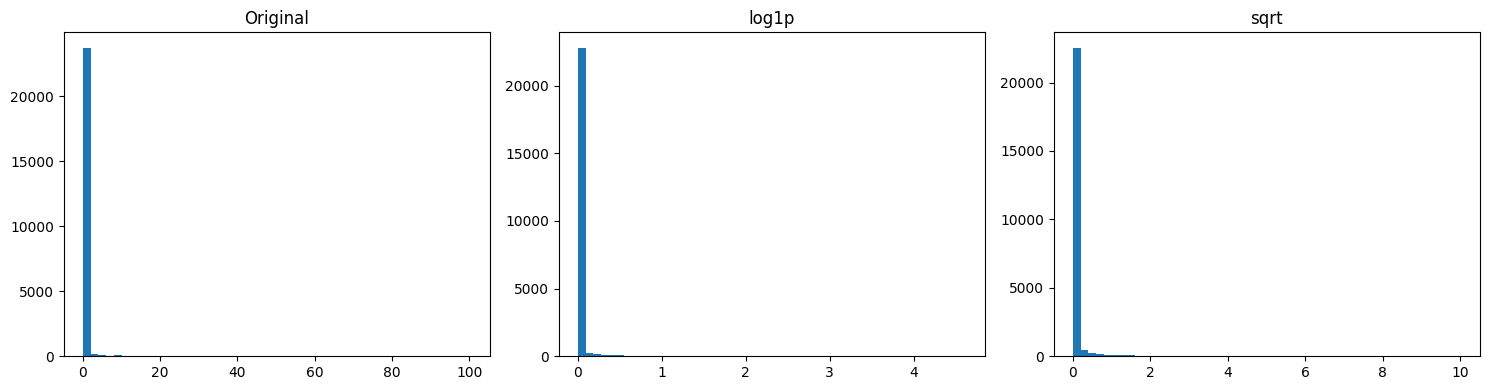

In [105]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# original
axes[0].hist(y_train_c, bins=50)
axes[0].set_title("Original")

# log1p
axes[1].hist(np.log1p(y_train_c), bins=50)
axes[1].set_title("log1p")

# sqrt
axes[2].hist(np.sqrt(y_train_c), bins=50)
axes[2].set_title("sqrt")

plt.tight_layout()
plt.savefig("target_distributions.png")

# also check skewness
print(f"Original skew:  {stats.skew(y_train_c):.3f}")
print(f"log1p skew:     {stats.skew(np.log1p(y_train_c)):.3f}")
print(f"sqrt skew:      {stats.skew(np.sqrt(y_train_c)):.3f}")

going to add in the logistic regression results data that were done in the logistic regression notebook, and see if this helps the results:

In [ ]:


#confusion matrix cmap
same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)

# #we need to make our target varaible from a % impact into a binary variable
y_train_new = (y_train_c > 0).astype(int)
y_test_new = (y_test_c > 0).astype(int)


In [184]:
# X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
#                          X_test_wo_grid[cols_wo_grid_hgb], y_test_c


logistic_regression_model = make_pipeline(StandardScaler(), 
                LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))

logistic_regression_model.fit(X_train_wo_grid, y_train_new)

probabilities = logistic_regression_model.predict_proba(X_test_wo_grid)[:, 1]  # probability of being impacted
# predictions_updated = (probabilities >= 0.669109).astype(int)
preds = logistic_regression_model.predict(X_test_wo_grid)
preds_2 = (probabilities >= 0.65).astype(int)

results = pd.DataFrame({
    "impacted":    preds,
    "probability": probabilities.round(3),
    "actual": y_test_new.values
})
results["impacted"] = results["impacted"].map({1: "Impacted", 0: "Not Impacted"})

# "stratified" respects class imbalance, better than "most_frequent" for imbalanced data
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train_wo_grid, y_train_new)

dummy_preds = dummy.predict(X_test_wo_grid)
dummy_probs = dummy.predict_proba(X_test_wo_grid)[:, 1]

In [149]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.65, 0.7]

print(f"{'Threshold':<12} {'Precision':<11} {'Recall':<10} {'F1':<9} {'AUC':<10}")
print("-" * 52)
for t in thresholds:
    preds_t = (probabilities >= t).astype(int)
    print(f"{t:<12} "
          f"{precision_score(y_test_new, preds_t):<12.3f}"
          f"{recall_score(y_test_new, preds_t):<10.3f}"
          f"{f1_score(y_test_new, preds_t):<10.3f}"
          f"{roc_auc_score(y_test_new, preds_t):<10.3f}")
    

Threshold    Precision   Recall     F1        AUC       
----------------------------------------------------
0.3          0.162       0.912     0.275     0.639     
0.4          0.206       0.847     0.331     0.705     
0.5          0.263       0.693     0.382     0.716     
0.6          0.316       0.569     0.407     0.702     
0.65         0.341       0.514     0.410     0.690     
0.7          0.342       0.336     0.339     0.625     


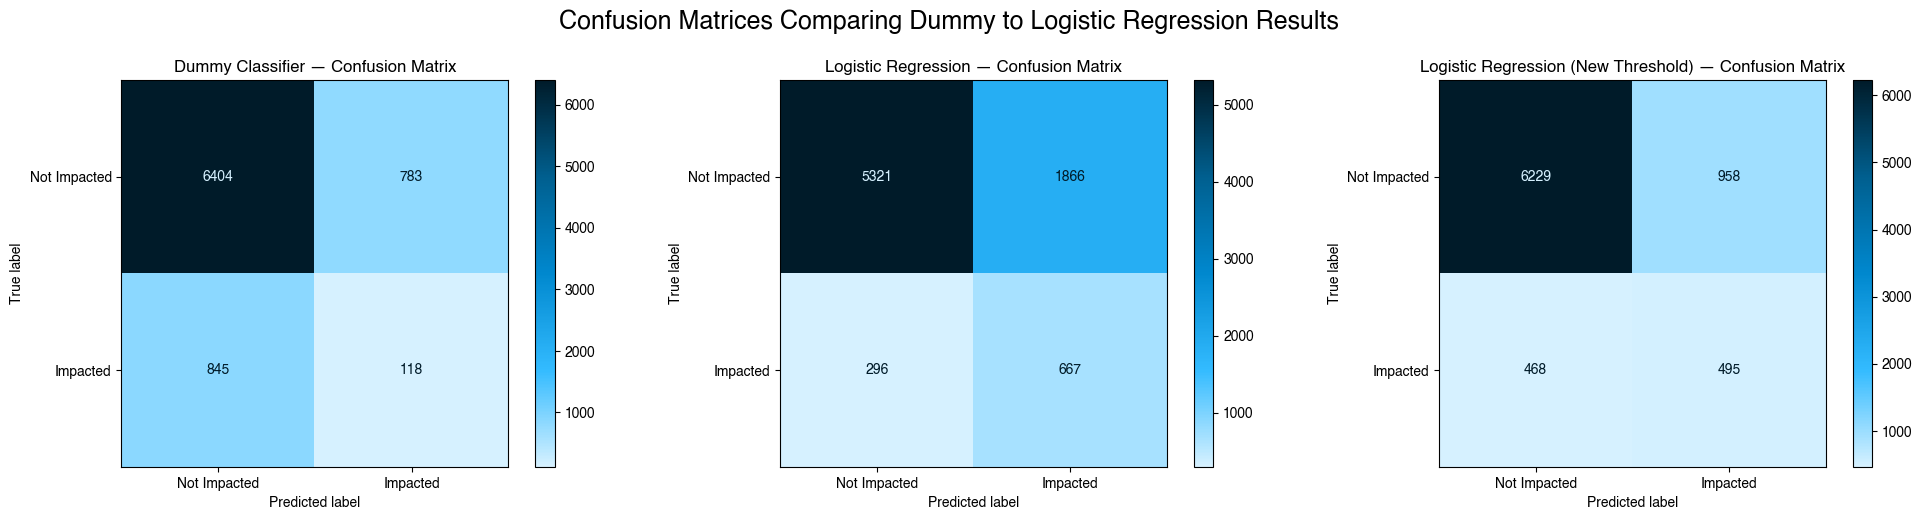

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_dummy = confusion_matrix(y_test_new, dummy_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[0]
)
axes[0].set_title("Dummy Classifier — Confusion Matrix")

cm = confusion_matrix(y_test_new, preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[1]
)
axes[1].set_title("Logistic Regression — Confusion Matrix")

cm = confusion_matrix(y_test_new, preds_2)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[2]
)
axes[2].set_title("Logistic Regression (New Threshold) — Confusion Matrix")

fig.suptitle(f'Confusion Matrices Comparing Dummy to Logistic Regression Results', fontsize=18, fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

In [172]:
print(f"{'':<13}{'Dummy':<11} {'Base':<8} {'New Threshold':<10}")
print("-" * 47)
print(f"{f"F1 Score":<12} "
          f"{f1_score(y_test_new, dummy_preds):<12.3f}"
          f"{f1_score(y_test_new, preds):<10.3f}"
          f"{f1_score(y_test_new, preds_2):<10.3f}")
print(f"{f"AUC Score":<12} "
          f"{roc_auc_score(y_test_new, dummy_preds):<12.3f}"
          f"{roc_auc_score(y_test_new, preds):<10.3f}"
          f"{roc_auc_score(y_test_new, preds_2):<10.3f}")

# print(f"Dummy F1 Score: {f1_score(y_test_new, dummy_preds)}, Base F1 Score: {f1_score(y_test_new, preds)},\nNew Threshold F1 Score: {f1_score(y_test_new, preds_2)}") 
# print(f"Dummy AUC Score: {roc_auc_score(y_test_new, dummy_preds)}, Base AUC Score: {roc_auc_score(y_test_new, preds)},\nNew Threshold AUC Score: {roc_auc_score(y_test_new, preds_2)}") 

             Dummy       Base     New Threshold
-----------------------------------------------
F1 Score     0.127       0.382     0.410     
AUC Score    0.507       0.716     0.690     


In [118]:
results.groupby("actual")["probability"].median()

actual
0    0.352
1    0.657
Name: probability, dtype: float64

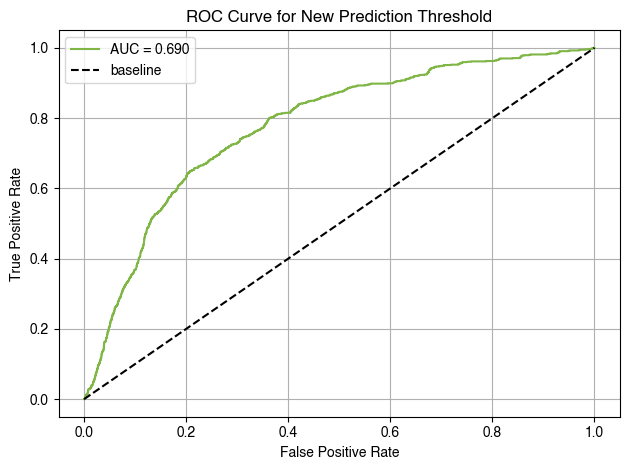

In [178]:
auc = roc_auc_score(y_test_new, preds_2)
fpr, tpr, _ = roc_curve(y_test_new, probabilities)
plt.rcParams['font.family'] = 'Helvetica'

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}",color='#7FB646')
plt.plot([0, 1], [0, 1], "k--", label="baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for New Prediction Threshold")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [192]:
# # get the probability predicted
prob_train = logistic_regression_model.predict_proba(X_train_wo_grid)[:, 1]
prob_test = logistic_regression_model.predict_proba(X_test_wo_grid)[:, 1]

#assign those to a column to filter our data on
logit_train = (prob_train >= 0.50).astype(int)
logit_test = (prob_test >= 0.50).astype(int)

# make a mask out of the above
nonzero_mask_train = logit_train == 1
nonzero_mask_test  = logit_test  == 1

X_train_li = X_train_wo_grid[nonzero_mask_train]
y_train_li = y_train_c[nonzero_mask_train]
X_test_li = X_test_wo_grid[nonzero_mask_test]
y_test_li = y_test_c[nonzero_mask_test]

Now, lets filter our model data and fit a model:

In [188]:
best_hgb_wo_grid.fit(X_train_li[cols_wo_grid_hgb], y_train_li)
print_consistent_results(best_hgb_wo_grid, X_train_li[cols_wo_grid_hgb], y_train_li, 
                         X_test_li[cols_wo_grid_hgb], y_test_li, cv=5)

Cross-validation R²:   0.0705 ± 0.0532
Cross-validation RMSE: 9.1309 ± 0.8891
Test Set R²:           0.0557
Test Set RMSE:         9.5750


In [193]:
# trying three random other models to see how they compare

# lightgbm
print("for RandomForest:")
rf_b_model = RandomForestRegressor(random_state=42, n_jobs=-1,verbose=0);
print_consistent_results(rf_b_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for ExtraTrees:")
ex_b_model = ExtraTreesRegressor(random_state=42, n_jobs=-1,verbose=0);
print_consistent_results(ex_b_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for LGBM:")
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0);
print_consistent_results(lgb_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for HistGradientBoostingRegressor:")
hgbr_model = HistGradientBoostingRegressor(random_state=42,verbose=0)
print_consistent_results(hgbr_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for BaggingRegressor:")
br_model = BaggingRegressor(random_state=42, n_jobs=-1, verbose=0)
print_consistent_results(br_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for GradientBoostingRegressor:")
gbr_model = GradientBoostingRegressor(random_state=42,verbose=0)
print_consistent_results(gbr_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

print("for XGBRegressor:")
xgb_b_model = xgb.XGBRegressor(random_state=42)
print_consistent_results(xgb_b_model, X_train_li, y_train_li, X_test_li, y_test_li, cv=5)

for RandomForest:


Cross-validation R²:   -0.0641 ± 0.0550
Cross-validation RMSE: 8.6465 ± 0.9042
Test Set R²:           -0.0727
Test Set RMSE:         9.2313
for ExtraTrees:
Cross-validation R²:   -0.1041 ± 0.0806
Cross-validation RMSE: 8.8065 ± 0.9744
Test Set R²:           -0.1043
Test Set RMSE:         9.3663
for LGBM:
Cross-validation R²:   0.0486 ± 0.0463
Cross-validation RMSE: 8.1801 ± 0.8854
Test Set R²:           0.0390
Test Set RMSE:         8.7373
for HistGradientBoostingRegressor:
Cross-validation R²:   0.0520 ± 0.0470
Cross-validation RMSE: 8.1671 ± 0.9045
Test Set R²:           0.0375
Test Set RMSE:         8.7441
for BaggingRegressor:
Cross-validation R²:   -0.1330 ± 0.0785
Cross-validation RMSE: 8.9039 ± 0.7866
Test Set R²:           -0.1147
Test Set RMSE:         9.4101
for GradientBoostingRegressor:
Cross-validation R²:   0.0617 ± 0.0370
Cross-validation RMSE: 8.1270 ± 0.8965
Test Set R²:           0.0562
Test Set RMSE:         8.6588
for XGBRegressor:
Cross-validation R²:   -0.1077 ± 0

In [ ]:
#Results: filter at 0.65
# for RandomForest:
# Cross-validation R²:   -0.0997 ± 0.0644
# Cross-validation RMSE: 9.9391 ± 1.0518
# Test Set R²:           -0.1316
# Test Set RMSE:         10.4818
# for ExtraTrees:
# Cross-validation R²:   -0.1223 ± 0.1013
# Cross-validation RMSE: 10.0388 ± 1.1693
# Test Set R²:           -0.1154
# Test Set RMSE:         10.4065
# for LGBM:
# Cross-validation R²:   0.0299 ± 0.0418
# Cross-validation RMSE: 9.3403 ± 0.9951
# Test Set R²:           0.0117
# Test Set RMSE:         9.7957
# for HistGradientBoostingRegressor:
# Cross-validation R²:   0.0334 ± 0.0431
# Cross-validation RMSE: 9.3239 ± 0.9994
# Test Set R²:           0.0067
# Test Set RMSE:         9.8201
# for BaggingRegressor:
# Cross-validation R²:   -0.1601 ± 0.1172
# Cross-validation RMSE: 10.2114 ± 1.2776
# Test Set R²:           -0.1770
# Test Set RMSE:         10.6897
# for GradientBoostingRegressor:
# Cross-validation R²:   0.0484 ± 0.0409
# Cross-validation RMSE: 9.2638 ± 1.0926
# Test Set R²:           0.0437
# Test Set RMSE:         9.6359
# for XGBRegressor:
# Cross-validation R²:   -0.1107 ± 0.0795
# Cross-validation RMSE: 9.9750 ± 0.9526
# Test Set R²:           -0.0724
# Test Set RMSE:         10.2040

# results: filter at 0.60
# for RandomForest:
# Cross-validation R²:   -0.0992 ± 0.0693
# Cross-validation RMSE: 9.9261 ± 1.0335
# Test Set R²:           -0.0936
# Test Set RMSE:         10.2909
# for ExtraTrees:
# Cross-validation R²:   -0.1303 ± 0.1051
# Cross-validation RMSE: 10.0679 ± 1.1934
# Test Set R²:           -0.1135
# Test Set RMSE:         10.3842
# for LGBM:
# Cross-validation R²:   0.0336 ± 0.0447
# Cross-validation RMSE: 9.3136 ± 0.9853
# Test Set R²:           0.0181
# Test Set RMSE:         9.7510
# for HistGradientBoostingRegressor:
# Cross-validation R²:   0.0426 ± 0.0435
# Cross-validation RMSE: 9.2695 ± 0.9676
# Test Set R²:           -0.0099
# Test Set RMSE:         9.8892
# for BaggingRegressor:
# Cross-validation R²:   -0.1523 ± 0.0867
# Cross-validation RMSE: 10.1565 ± 1.0442
# Test Set R²:           -0.1780
# Test Set RMSE:         10.6807
# for GradientBoostingRegressor:
# Cross-validation R²:   0.0521 ± 0.0397
# Cross-validation RMSE: 9.2398 ± 1.0982
# Test Set R²:           0.0429
# Test Set RMSE:         9.6271
# for XGBRegressor:
# Cross-validation R²:   -0.1517 ± 0.0822
# Cross-validation RMSE: 10.1445 ± 0.9175
# Test Set R²:           -0.0960
# Test Set RMSE:         10.3021

# Results: for 0.5
# for RandomForest:
# Cross-validation R²:   -0.0641 ± 0.0550
# Cross-validation RMSE: 8.6465 ± 0.9042
# Test Set R²:           -0.0727
# Test Set RMSE:         9.2313
# for ExtraTrees:
# Cross-validation R²:   -0.1041 ± 0.0806
# Cross-validation RMSE: 8.8065 ± 0.9744
# Test Set R²:           -0.1043
# Test Set RMSE:         9.3663
# for LGBM:
# Cross-validation R²:   0.0486 ± 0.0463
# Cross-validation RMSE: 8.1801 ± 0.8854
# Test Set R²:           0.0390
# Test Set RMSE:         8.7373
# for HistGradientBoostingRegressor:
# Cross-validation R²:   0.0520 ± 0.0470
# Cross-validation RMSE: 8.1671 ± 0.9045
# Test Set R²:           0.0375
# Test Set RMSE:         8.7441
# for BaggingRegressor:
# Cross-validation R²:   -0.1330 ± 0.0785
# Cross-validation RMSE: 8.9039 ± 0.7866
# Test Set R²:           -0.1147
# Test Set RMSE:         9.4101
# for GradientBoostingRegressor:
# Cross-validation R²:   0.0617 ± 0.0370
# Cross-validation RMSE: 8.1270 ± 0.8965
# Test Set R²:           0.0562
# Test Set RMSE:         8.6588
# for XGBRegressor:
# Cross-validation R²:   -0.1077 ± 0.0843
# Cross-validation RMSE: 8.8165 ± 0.9306
# Test Set R²:           -0.0952
# Test Set RMSE:         9.3274

# base with no filtering
#Results:
# for RandomForest:
# mean CV score: -0.0098
# Test Set R²: -0.0484
# for ExtraTrees:
# mean CV score: -0.0612
# Test Set R²: -0.1003
# for LGBM:
# mean CV score: 0.0885
# Test Set R²: 0.1014
# for HistGradientBoostingRegressor:
# mean CV score: 0.0975
# Test Set R²: 0.1046
# for BaggingRegressor:
# mean CV score: -0.0602
# Test Set R²: -0.1155
# for GradientBoostingRegressor:
# mean CV score: 0.0820
# Test Set R²: 0.0679
# for XGBRegressor:
# mean CV score: -0.0106
# Test Set R²: 0.0030
# for SVR:
# mean CV score: -0.0103
# Test R²: -0.0110

Ok, that didn't make this any better, we're going to just add in the prediction as part of the data without filtering anything out:

In [213]:
# # get the probability predicted - from before:
# prob_train = logistic_regression_model.predict_proba(X_train_wo_grid)[:, 1]
# prob_test = logistic_regression_model.predict_proba(X_test_wo_grid)[:, 1]

# make copy of dataframs of predictors
X_train_wo_grid_w_pred = X_train_wo_grid.copy()
X_test_wo_grid_w_pred = X_test_wo_grid.copy()

# add a column to dataframes
X_train_wo_grid_w_pred['logit_prob'] = prob_train
X_test_wo_grid_w_pred['logit_prob'] = prob_test

In [ ]:
X_train_wo_grid.drop(columns=['log_pred_impacted'],inplace=True)
X_test_wo_grid.drop(columns=['log_pred_impacted'],inplace=True)
# log_pred_impacted

Going to do some testing in concession with all the predictions data:

In [216]:
mean_columns = [col for col in X_train_wo_grid.columns if 'mean' in col]
median_columns = [col for col in X_train_wo_grid.columns if 'median' in col]

X_train_wo_grid_medians = X_train_wo_grid_w_pred.drop(columns=mean_columns)
X_test_wo_grid_medians = X_test_wo_grid_w_pred.drop(columns=mean_columns)

X_train_wo_grid_means = X_train_wo_grid_w_pred.drop(columns=median_columns)
X_test_wo_grid_means = X_test_wo_grid_w_pred.drop(columns=median_columns)


Ok, now try the baseline on all of these combinations (3 combos):

In [217]:
best_lgbm_tester(best_lgbm_wo_grid,X_train_wo_grid_medians,y_train,X_test,y_test,thresh=0.9)

Cross-validation R²:   0.0889 ± 0.0244
Cross-validation RMSE: 4.7256 ± 0.3744
Test Set R²:           0.0833
Test Set RMSE:         4.9997
Cross-validation R²:   0.0947 ± 0.0353
Cross-validation RMSE: 4.7088 ± 0.3673
Test Set R²:           0.0888
Test Set RMSE:         4.9847


In [218]:
best_lgbm_tester(best_lgbm_wo_grid,X_train_wo_grid_means,y_train_c,X_test_wo_grid_means,y_test_c,thresh=0.9)

Cross-validation R²:   0.1044 ± 0.0375
Cross-validation RMSE: 4.6861 ± 0.3995
Test Set R²:           0.0959
Test Set RMSE:         4.9653
Cross-validation R²:   0.0947 ± 0.0389
Cross-validation RMSE: 4.7076 ± 0.3563
Test Set R²:           0.1057
Test Set RMSE:         4.9384


In [226]:
print_consistent_results(lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0), X_train_wo_grid_medians,y_train_c,
                         X_test_wo_grid_medians,y_test_c, cv=5)

Cross-validation R²:   0.0595 ± 0.0402
Cross-validation RMSE: 4.7971 ± 0.3469
Test Set R²:           0.0963
Test Set RMSE:         4.9644


In [228]:
print_consistent_results(lgb.LGBMRegressor(random_state=42, n_jobs=-1,verbose=0), X_train_wo_grid_means,y_train_c,
                         X_test_wo_grid_means,y_test_c, cv=5)

Cross-validation R²:   0.0724 ± 0.0435
Cross-validation RMSE: 4.7646 ± 0.3581
Test Set R²:           0.0852
Test Set RMSE:         4.9946


quick basic test with values:

In [219]:
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid_medians,y_train_c,
                         X_test_wo_grid_medians,y_test_c, cv=5)

Cross-validation R²:   0.0920 ± 0.0333
Cross-validation RMSE: 4.7155 ± 0.3588
Test Set R²:           0.1055
Test Set RMSE:         4.9390


In [220]:
print_consistent_results(best_hgb_wo_grid, X_train_wo_grid_means, y_train_c,
                         X_test_wo_grid_means,y_test_c, cv=5)

Cross-validation R²:   0.0999 ± 0.0272
Cross-validation RMSE: 4.6975 ± 0.3819
Test Set R²:           0.0882
Test Set RMSE:         4.9863


In [223]:
print_consistent_results(HistGradientBoostingRegressor(random_state=42), X_train_wo_grid_medians,y_train_c,
                         X_test_wo_grid_medians,y_test_c, cv=5)

Cross-validation R²:   0.0711 ± 0.0385
Cross-validation RMSE: 4.7677 ± 0.3472
Test Set R²:           0.1036
Test Set RMSE:         4.9442


In [224]:
print_consistent_results(HistGradientBoostingRegressor(random_state=42), X_train_wo_grid_means,y_train_c,
                         X_test_wo_grid_means,y_test_c, cv=5)

Cross-validation R²:   0.0800 ± 0.0274
Cross-validation RMSE: 4.7482 ± 0.3744
Test Set R²:           0.0771
Test Set RMSE:         5.0167


In [ ]:
def best_hgbr_tester():
    

In [ ]:
param_grid_hgb = {
    "max_iter":        [100, 200, 300],
    "max_depth":       [3, 5, 7, None],
    "learning_rate":   [0.01, 0.05, 0.1],
    "min_samples_leaf":[10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

grid_hgb_wo = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid_hgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_hgb_wo.fit(X_train_wo_grid[cols_wo_grid_hgb], y_train_c)
best_hgb_wo_grid = grid_hgb_wo.best_estimator_

print("Best R²:    ", grid_hgb_wo.best_score_.round(3))
print("Best params:", grid_hgb_wo.best_params_)

print_consistent_results(best_hgb_wo_grid, X_train_wo_grid[cols_wo_grid_hgb], y_train_c, 
                         X_test_wo_grid[cols_wo_grid_hgb], y_test_c, cv=5)